In [1]:
import arviz as az

In [2]:
stan = az.from_json("result_radon_stan.json")
bjnuts = az.from_json("results_radon_bjnuts.json")
smc = az.from_json("results_radon_smc.json")

/Users/carlosiguaran/repos/smc/.venv/lib/python3.9/site-packages/arviz/data/base.py:221: UserWarning: More chains (4000) than draws (777). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

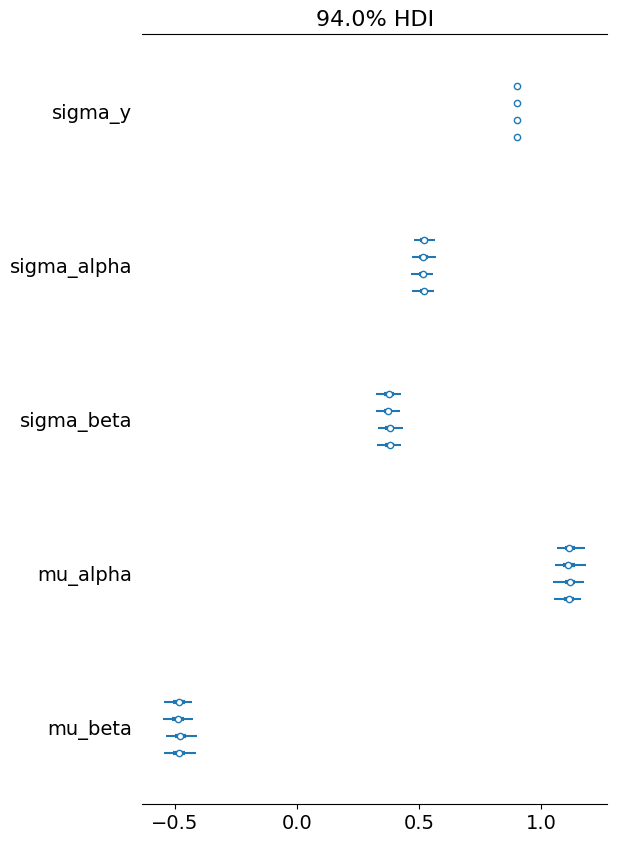

In [3]:
az.plot_forest(stan, var_names=["sigma_y","sigma_alpha", "sigma_beta", "mu_alpha", "mu_beta"])

In [4]:
stan.posterior

<xarray.Dataset> Size: 50MB
Dimensions:          (chain: 4, draw: 1000, alpha_raw_dim_0: 386,
                      beta_raw_dim_0: 386, alpha_dim_0: 386, beta_dim_0: 386)
Coordinates:
  * chain            (chain) int64 32B 0 1 2 3
  * draw             (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
  * alpha_raw_dim_0  (alpha_raw_dim_0) int64 3kB 0 1 2 3 4 ... 382 383 384 385
  * beta_raw_dim_0   (beta_raw_dim_0) int64 3kB 0 1 2 3 4 ... 382 383 384 385
  * alpha_dim_0      (alpha_dim_0) int64 3kB 0 1 2 3 4 5 ... 381 382 383 384 385
  * beta_dim_0       (beta_dim_0) int64 3kB 0 1 2 3 4 5 ... 381 382 383 384 385
Data variables:
    sigma_y          (chain, draw) float64 32kB 0.9033 0.9075 ... 0.9015 0.906
    sigma_alpha      (chain, draw) float64 32kB 0.5215 0.5168 ... 0.5138 0.4838
    sigma_beta       (chain, draw) float64 32kB 0.4193 0.4251 ... 0.4468 0.3825
    alpha_raw        (chain, draw, alpha_raw_dim_0) float64 12MB 0.9399 ... -...
    beta_raw         (chain, draw, beta_raw_dim_0) float64 12MB 1.445 ... 1.1
    mu_alpha         (chain, draw) float64 32kB 1.12 1.109 1.119 ... 1.1 1.101
    mu_beta          (chain, draw) float64 32kB -0.5085 -0.5098 ... -0.4468
    alpha            (chain, draw, alpha_dim_0) float64 12MB 1.61 ... -0.2757
    beta             (chain, draw, beta_dim_0) float64 12MB 0.0973 ... -0.02615
Attributes:
    created_at:          2024-09-04T11:52:18.397528
    arviz_version:       0.17.1
    stan_version:        2.35.0
    model:               radon_model
    num_draws_sampling:  1000

In [5]:
as_array = bjnuts.posterior.to_array().to_numpy().reshape(4,1000,777)
bj_nuts_reformated = {"sigma_y" : as_array[:,:,0],
"sigma_alpha"  : as_array[:,:,1],
"sigma_beta" : as_array[:,:,2],
"alpha_raw" :  as_array[:,:,3:3+386],
"beta_raw" : as_array[:,:,3+386:3+386+386],
"mu_alpha":as_array[:,:,-2],
"mu_beta":as_array[:,:,-1]}

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

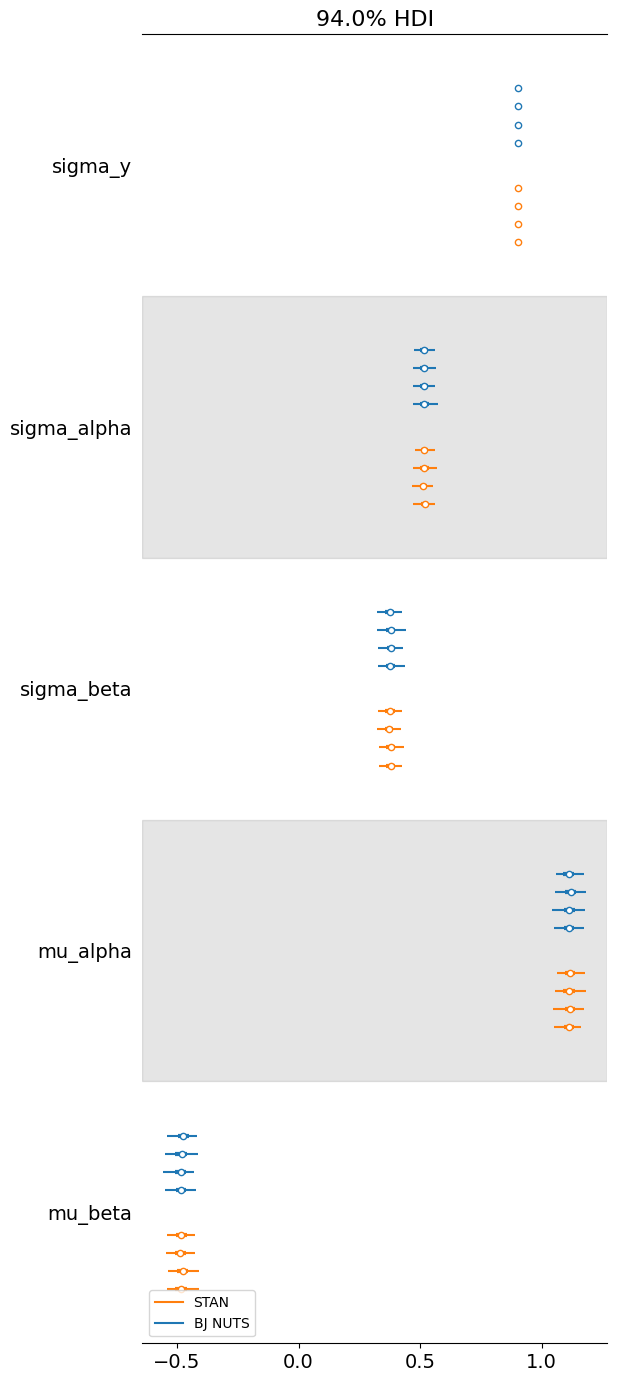

In [8]:
az.plot_forest([bj_nuts_reformated, stan],model_names=["BJ NUTS", "STAN"],var_names=["sigma_y","sigma_alpha", "sigma_beta", "mu_alpha", "mu_beta"])

In [9]:
smc.posterior

<xarray.Dataset> Size: 25MB
Dimensions:  (chain: 4000, draw: 777)
Coordinates:
  * chain    (chain) int64 32kB 0 1 2 3 4 5 6 ... 3994 3995 3996 3997 3998 3999
  * draw     (draw) int64 6kB 0 1 2 3 4 5 6 7 ... 770 771 772 773 774 775 776
Data variables:
    x        (chain, draw) float64 25MB 0.8957 0.509 0.3965 ... 1.127 -0.5164
Attributes:
    created_at:     2024-09-04T02:50:37.116544
    arviz_version:  0.17.1

In [27]:
as_array = smc.posterior.to_array().to_numpy().reshape(4000,777)
particles_to_use=500
smc_reformated = {"sigma_y" : as_array[:particles_to_use,0],
"sigma_alpha"  : as_array[:particles_to_use,1],
"sigma_beta" : as_array[:particles_to_use,2],
"alpha_raw" :  as_array[:particles_to_use,3:3+386],
"beta_raw" : as_array[:particles_to_use,3+386:3+386+386],
"mu_alpha":as_array[:particles_to_use,-2],
"mu_beta":as_array[:particles_to_use,-1]}
for k in smc_reformated:
    smc_reformated[k] = smc_reformated[k].reshape(1,particles_to_use, -1)

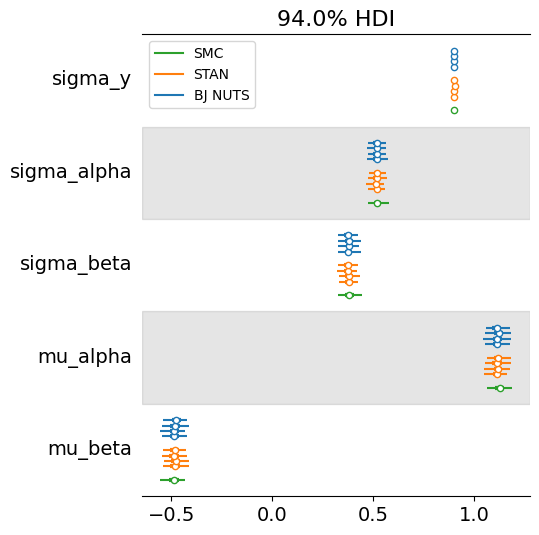

In [33]:

az.plot_forest([bj_nuts_reformated,
                stan,
                smc_reformated], 
               model_names=["BJ NUTS", "STAN", "SMC"],
               var_names=["sigma_y",
                          "sigma_alpha", 
                          "sigma_beta", 
                          "mu_alpha", 
                          "mu_beta"],
              figsize=(5, 6));

In [24]:
smc_reformated.keys()

dict_keys(['sigma_y', 'sigma_alpha', 'sigma_beta', 'alpha_raw', 'beta_raw', 'mu_alpha', 'mu_beta'])

In [26]:
for k in smc_reformated:
    print(smc_reformated[k].shape)

(1, 500)
(1, 500)
(1, 500)
(1, 193000)
(1, 193000)
(1, 500)
(1, 500)
